# Why does SCREAM look more cloudy than LASSO?
## A fair comparison on three days at the ARM SGP site

**The setup.** We have two model simulations of clouds over the central US (ARM SGP site) on three different days. One is **SCREAM**, a 5 km global climate model. The other is **LASSO**, a high-resolution (250 m) reference simulation that the cloud community treats as a near-ground-truth benchmark. We also have **ARM observations** (microwave radiometer LWP, radar cloud mask) as an independent anchor.

**The puzzle.** When we plot the cloud fraction side by side, SCREAM looks *much* more cloudy than LASSO. But the two models do not count clouds the same way:

- LASSO counts a grid cell as cloudy if it carries actual cloud water +   rainwater (specifically, `qc + qr > 1e-7 kg/kg`; Zhang et al. 2024 GRL).
- SCREAM has an internal label called `cldfrac_tot` that *guesses* how cloudy   a grid box is from the local temperature and moisture variability, not   from counting actual water.

So our first question is: **is the SCREAM-vs-LASSO gap real, or just a counting issue?**

**The short answer.** The gap is real, *but the cause is different on different days.* On the shallow-cloud day (2019-05-17), SCREAM is labeling grid boxes cloudy when there is barely any water in them — **clouds without water**. On the two active-convection days (2018-07-09, 2019-09-29), SCREAM is producing too much water everywhere — **too much water**. The rest of this notebook shows that finding in three figures.


In [1]:
# Setup. Self-contained: no external imports from other notebook files.
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import netCDF4 as nc

warnings.filterwarnings('ignore', category=RuntimeWarning)

# LASSO's own cloud-water rule (Zhang et al. 2024 GRL, Methods).
# A grid cell is 'cloudy' if its cloud + rain water exceeds this threshold.
WATER_THRESH = 1e-7   # kg/kg, applied to qc + qr
CF_THRESH    = 0.01   # what fraction counts as 'cloud' in any of the three CF fields

# Find the project root by walking up the directory tree.
_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    if list(_cand.glob('scream_dpxx_LASSO_SGP_*.nc')):
        ROOT = _cand
        break
else:
    raise FileNotFoundError(
        'Cannot find LASSO repo root (no SCREAM .nc files in cwd or parents). '
        'Open Jupyter from inside the LASSO project.'
    )

# Three case days, listed in calendar order (May -> July -> September).
CASES = {
    '0517': {'date': '2019-05-17', 'sim': 4, 'short_label': 'shallow cumulus'},
    '0709': {'date': '2018-07-09', 'sim': 8, 'short_label': 'deep convection'},
    '0929': {'date': '2019-09-29', 'sim': 4, 'short_label': 'fall transition'},
}
for k, v in CASES.items():
    d = v['date'].replace('-', '')
    v['f_scream']  = ROOT / f"scream_dpxx_LASSO_SGP_{v['date']}.fullfield.AVERAGE.nhours_x1.{v['date']}-43200.nc"
    v['f_obsmodz'] = ROOT / 'WRFandob' / k / f"sgplassodiagobsmodz{v['sim']}C1.m1.{d}.120000.nc"
    v['f_obsmod']  = ROOT / 'WRFandob' / k / f"sgplassodiagobsmod{v['sim']}C1.m1.{d}.120000.nc"
    v['f_mod']     = ROOT / 'WRFandob' / k / f"sgplassomod{v['sim']}C1.m1.{d}.120000.nc"

CASE_ORDER = ['0517', '0709', '0929']
CASE_COLOR = {'0517': '#0072B2', '0709': '#D55E00', '0929': '#009E73'}

FIG_JGR = ROOT / 'figs' / 'jgr'
FIG_JGR.mkdir(parents=True, exist_ok=True)

# Slide-friendly plot defaults.
plt.rcParams.update({
    'figure.dpi':        130,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   11,
    'figure.titlesize':  14,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.0,
    'lines.linewidth':   1.8,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.6,
})

print(f'Project root: {ROOT}')
print(f'Rule for counting a cloudy cell: qc + qr > {WATER_THRESH:.0e} kg/kg '
      '(LASSO definition, Zhang 2024 GRL)')


Project root: C:\Users\yij\Documents\Projects\LASSO
Rule for counting a cloudy cell: qc + qr > 1e-07 kg/kg (LASSO definition, Zhang 2024 GRL)


## Figure 1 — Counting clouds two ways, on the same SCREAM data

If we apply LASSO's counting rule (`qc + qr > 1e-7 kg/kg`) to SCREAM, the comparison becomes apples-to-apples. For each day we compare:

- **SCREAM cloud label** — `cldfrac_tot`, the internal cloud-fraction   diagnostic, divided by LASSO's cloud fraction.
- **SCREAM actual water** — fraction of SCREAM's 100 grid columns that have   real `qc + qr > 1e-7 kg/kg`, divided by LASSO's cloud fraction.

Bars at the dashed line (=1) mean SCREAM and LASSO agree on how cloudy the day was. Bars above 1 mean SCREAM is more cloudy.


In [2]:
# Load each case; compute three cloud-occurrence numbers per case:
#   - SCREAM 'cloud label' (cldfrac_tot)
#   - SCREAM 'actual water' (qc + qr > 1e-7)
#   - LASSO cloud_fraction (reference)
def open_wrf_vap(path):
    """LASSO WRF VAP files: 'height' is dim+var so xarray drops it; reattach as height_km."""
    ds  = xr.open_dataset(path, decode_coords=False, drop_variables=['height'])
    raw = nc.Dataset(path)
    if 'height' in raw.variables:
        ds['height_km'] = (raw.variables['height'].dimensions, raw.variables['height'][:])
    raw.close()
    return ds

rows = []
for short in CASE_ORDER:
    c   = CASES[short]
    sc  = xr.open_dataset(c['f_scream'])
    omz = open_wrf_vap(c['f_obsmodz'])

    cf_label    = sc['cldfrac_tot'].mean('ncol').values                          # SCREAM internal label
    cf_water    = ((sc['qc'] + sc['qr']) > WATER_THRESH).mean('ncol').values    # SCREAM actual water
    cf_lasso    = omz['cloud_fraction'].values                                   # LASSO reference

    rows.append(dict(
        case=short, date=c['date'],
        occ_label = float((cf_label >= CF_THRESH).mean()),
        occ_water = float((cf_water >= CF_THRESH).mean()),
        occ_lasso = float((cf_lasso >= CF_THRESH).mean()),
    ))
    sc.close(); omz.close()

m = pd.DataFrame(rows).set_index('case').loc[CASE_ORDER].reset_index()
m['ratio_label_vs_lasso'] = m['occ_label'] / m['occ_lasso']
m['ratio_water_vs_lasso'] = m['occ_water'] / m['occ_lasso']
m.round(2)


,case,date,occ_label,occ_water,occ_lasso,ratio_label_vs_lasso,ratio_water_vs_lasso
0,0517,2019-05-17,0.21,0.11,0.05,4.25,2.24
1,0709,2018-07-09,0.10,0.23,0.06,1.63,3.57
2,0929,2019-09-29,0.14,0.20,0.09,1.58,2.32


saved -> C:\Users\yij\Documents\Projects\LASSO\figs\jgr\fig16_lasso_consistent_ratio.png


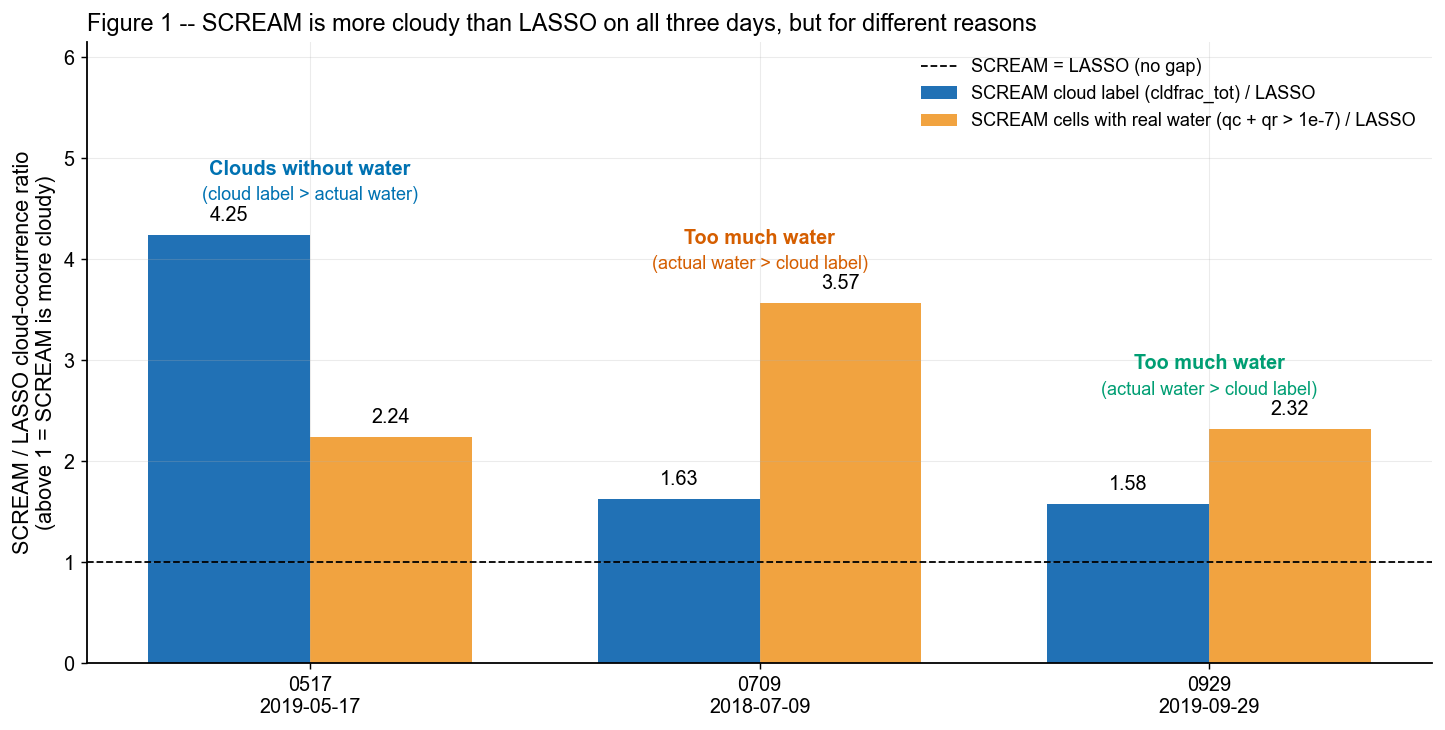

In [3]:
# Figure 1.  One bar chart, two bars per case.
fig, ax = plt.subplots(1, 1, figsize=(11.0, 5.5), constrained_layout=True)
xpos = np.arange(len(CASE_ORDER))
w    = 0.36
LABEL_COLOR = '#2171B5'    # blue: SCREAM internal cloud label
WATER_COLOR = '#F1A340'    # orange: SCREAM cells with real water
labels = [f"{c}\n{CASES[c]['date']}" for c in CASE_ORDER]

v_lbl = m['ratio_label_vs_lasso'].values
v_wat = m['ratio_water_vs_lasso'].values
b1 = ax.bar(xpos - w/2, v_lbl, w, color=LABEL_COLOR,
            label='SCREAM cloud label (cldfrac_tot) / LASSO')
b2 = ax.bar(xpos + w/2, v_wat, w, color=WATER_COLOR,
            label='SCREAM cells with real water (qc + qr > 1e-7) / LASSO')
ax.axhline(1.0, color='k', ls='--', lw=1.0, label='SCREAM = LASSO (no gap)')

ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_ylabel('SCREAM / LASSO cloud-occurrence ratio\n(above 1 = SCREAM is more cloudy)')
ax.legend(frameon=False, loc='upper right', fontsize=10)

for bar, val in list(zip(b1, v_lbl)) + list(zip(b2, v_wat)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.10,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11)
y_top = max(v_lbl.max(), v_wat.max()) * 1.45
ax.set_ylim(0, y_top)

# Plain-English explanation pinned above each pair of bars.
messages = {
    '0517': ('Clouds without water', 'cloud label > actual water'),
    '0709': ('Too much water',       'actual water > cloud label'),
    '0929': ('Too much water',       'actual water > cloud label'),
}
for i, c in enumerate(CASE_ORDER):
    top   = max(v_lbl[i], v_wat[i])
    head, sub = messages[c]
    ax.text(i, top + 0.55, head, ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=CASE_COLOR[c])
    ax.text(i, top + 0.30, f'({sub})', ha='center', va='bottom',
            fontsize=10, color=CASE_COLOR[c])

ax.set_title('Figure 1 -- SCREAM is more cloudy than LASSO on all three days, but for '
             'different reasons',
             loc='left', fontsize=13)
out_png = FIG_JGR / 'fig16_lasso_consistent_ratio.png'
fig.savefig(out_png)
print('saved ->', out_png)
plt.show()


**Reading Figure 1.**

- *0517 — clouds without water.* The blue bar (4.25) is much higher than the   orange bar (2.24). SCREAM's internal cloud label is more cloudy than the   *same SCREAM run*'s actual water field. The cloud label is over-counting.
- *0709 and 0929 — too much water.* The orange bar is *higher* than the blue   bar. SCREAM's actual water is already more cloudy than LASSO, and the   cloud label is actually a little conservative. So this is not a   label-vs-water mismatch — it is just too much water everywhere.

Either way, SCREAM is too cloudy versus LASSO — but on different days the fix would have to look in different places.


## Figure 2 — How much water sits in the column? (LWP)

Cloud occurrence tells us *how often* clouds appear. **LWP** (liquid water path) tells us *how much water* is in the column, in grams per square meter. We plot the daily cycle of LWP for SCREAM, LASSO, and the ARM **MWR** (microwave radiometer — the closest thing to ground truth for cloud water from above).


saved -> C:\Users\yij\Documents\Projects\LASSO\figs\jgr\fig16_lwp_diurnal.png


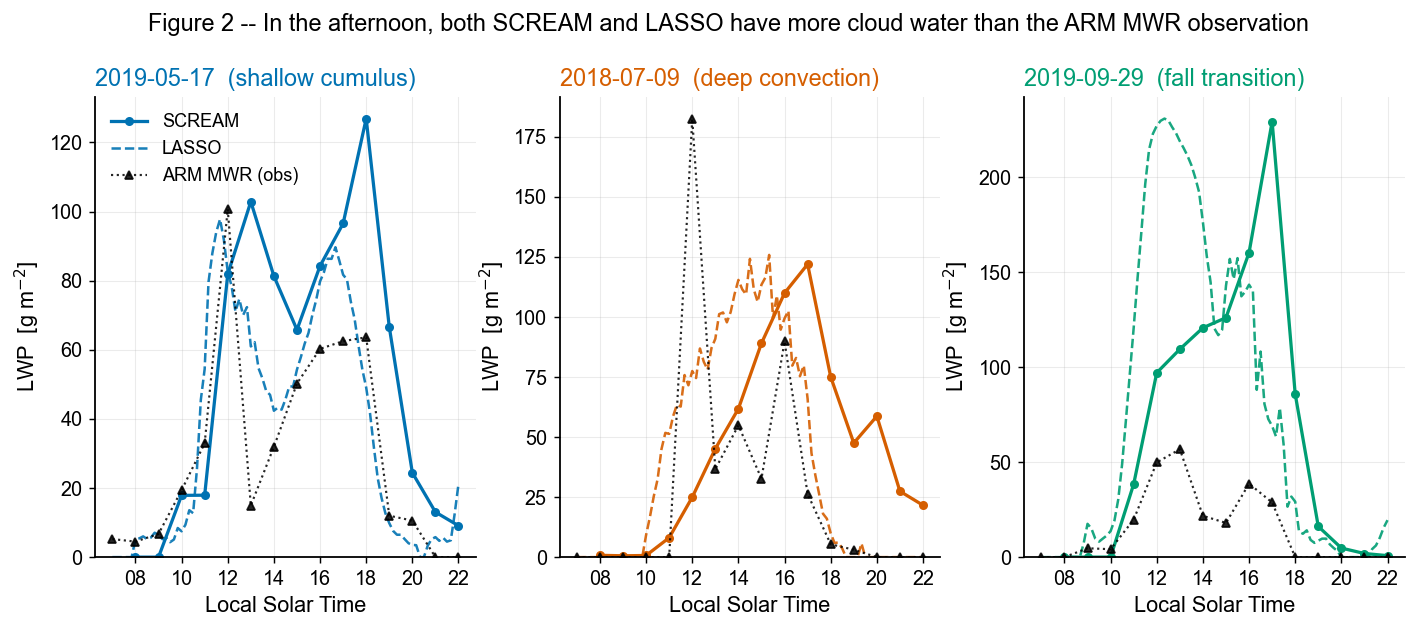

In [4]:
# Figure 2.  LWP daily cycle: SCREAM, LASSO, and the ARM MWR observation.
import matplotlib.dates as mdates

UTC_TO_LST = pd.Timedelta(hours=-5)
def to_lst(times):
    return pd.DatetimeIndex(times) + UTC_TO_LST

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.6), sharey=False,
                         gridspec_kw=dict(wspace=0.22))

for ax, short in zip(axes, CASE_ORDER):
    c   = CASES[short]
    sc  = xr.open_dataset(c['f_scream'])
    mod = open_wrf_vap(c['f_mod'])
    omd = open_wrf_vap(c['f_obsmod'])
    # CF flag attrs: source_type idx 0 = Observation, idx 1 = Model.
    fm = omd['source_type'].attrs.get('flag_meanings', '').lower()
    assert 'observation' in fm.split()[0], f'unexpected source_type for {short}: {fm!r}'

    t_sc  = to_lst(sc['time'].values)
    t_mod = to_lst(mod['time'].values)
    t_omd = to_lst(omd['time'].values)
    lwp_sc  = sc['LiqWaterPath'].mean('ncol').values * 1000.0    # kg/m2 -> g/m2
    lwp_lasso = mod['lwp'].values                                # g/m2
    lwp_mwr   = omd['lwp'].isel(source_type=0).values             # g/m2 (Observation)

    col = CASE_COLOR[short]
    ax.plot(t_sc,    lwp_sc,    '-o', color=col,     ms=4, lw=1.8, label='SCREAM')
    ax.plot(t_mod,   lwp_lasso, '--', color=col,     lw=1.4, alpha=0.9, label='LASSO')
    ax.plot(t_omd,   lwp_mwr,   ':^', color='black', ms=4, lw=1.2, alpha=0.85, label='ARM MWR (obs)')
    ax.set_title(f"{c['date']}  ({c['short_label']})", loc='left', color=col, fontsize=13)
    ax.set_xlabel('Local Solar Time')
    ax.set_ylabel(r'LWP  [g m$^{-2}$]')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    ax.set_ylim(bottom=0)
    sc.close(); mod.close(); omd.close()

axes[0].legend(loc='upper left', frameon=False, fontsize=10)
fig.suptitle('Figure 2 -- In the afternoon, both SCREAM and LASSO have more cloud water '
             'than the ARM MWR observation',
             fontsize=13, y=1.02)
out_png = FIG_JGR / 'fig16_lwp_diurnal.png'
fig.savefig(out_png, bbox_inches='tight')
print('saved ->', out_png)
plt.show()


**Reading Figure 2.**

- The solid coloured line (SCREAM) and the dashed coloured line (LASSO) both   shoot well above the black observed line in the afternoon (12–18 LST),   most dramatically on the deep-convection (07-09) and fall-transition   (09-29) days.
- This is the same afternoon LWP overshoot that Zhang et al. (2024, GRL)   documented for LASSO over 77 case days. We see it not only in LASSO but   also in SCREAM on the same days — two different models, same direction   of bias.
- The overshoot is largest on the two *too-much-water* days (07-09, 09-29)   that Figure 1 already flagged. Same story from a different angle.


## Figure 3 — Why is the LWP too high? The boundary-layer link

The **planetary boundary layer (PBL)** is the lowest part of the atmosphere (typically 0.5–2.5 km thick), where surface heating drives turbulent mixing. A boundary layer that grows too tall during the day funnels too much moist air aloft, which then condenses into too much cloud water.

Zhang et al. (2024) showed that in LASSO, the afternoon LWP and the afternoon PBL height are tightly correlated (r ≈ 0.60). Here we test the same coupling in SCREAM. For each case we scatter every column's afternoon (12–18 LST) PBL height against its column LWP, and fit a line. A positive slope means: when the boundary layer grows taller, LWP rises too — the Zhang fingerprint.


saved -> C:\Users\yij\Documents\Projects\LASSO\figs\jgr\fig16_pblh_lwp_mechanism.png

Per-case afternoon PBL-height vs LWP correlation:
  0517  2019-05-17  r = -0.138  (n = 700)
  0709  2018-07-09  r = +0.147  (n = 700)
  0929  2019-09-29  r = +0.450  (n = 700)


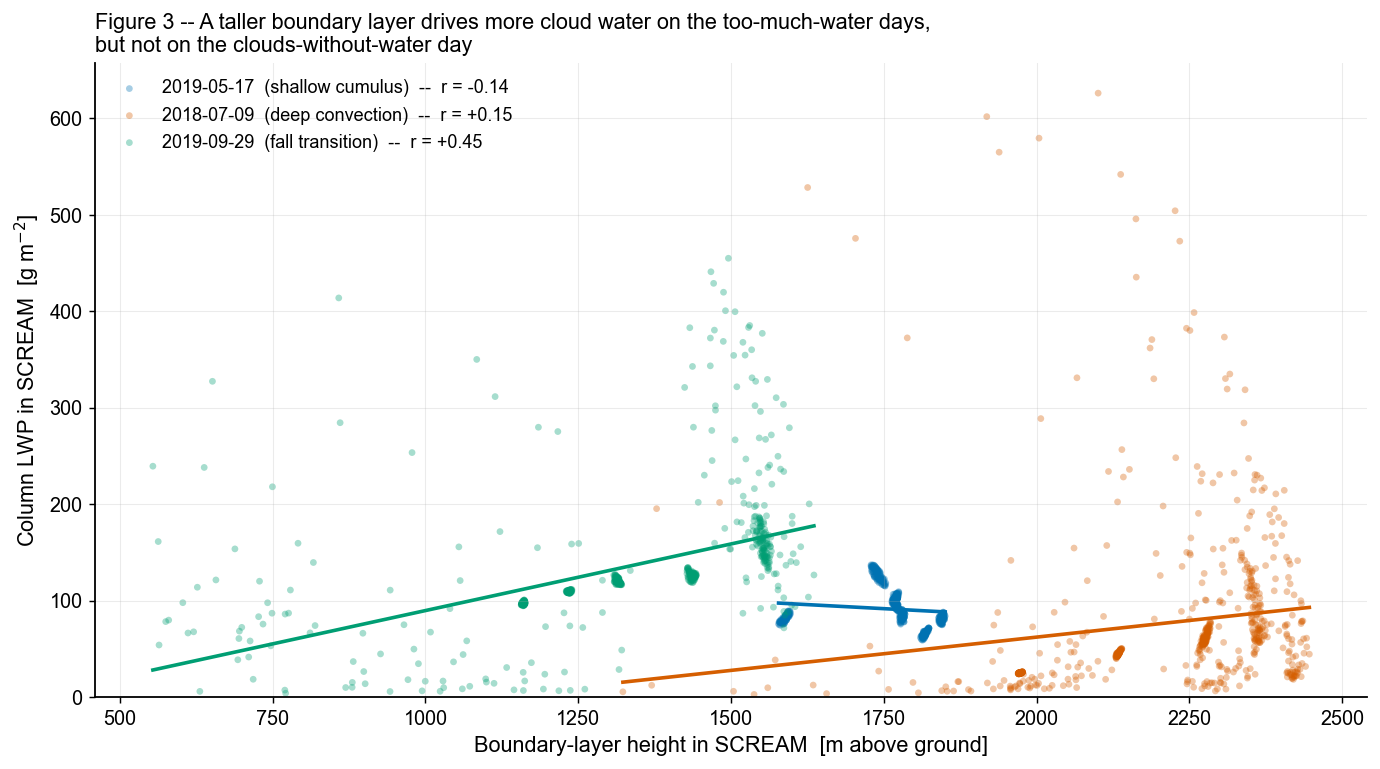

In [5]:
# Figure 3.  Per-case scatter of all afternoon (12-18 LST) (column, time) points:
# PBL height vs liquid water path. Coloured by case; line is a linear fit per case.
from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10.5, 5.8), constrained_layout=True)
summary = []
for short in CASE_ORDER:
    c     = CASES[short]
    sc    = xr.open_dataset(c['f_scream'])
    t_lst = to_lst(sc['time'].values)
    hour  = t_lst.hour + t_lst.minute / 60.0
    mask_aft = (hour >= 12) & (hour <= 18)

    pblh = sc['pbl_height'].isel(time=mask_aft).values             # m AGL
    lwp  = sc['LiqWaterPath'].isel(time=mask_aft).values * 1000.0  # g/m2
    pblh, lwp = pblh.flatten(), lwp.flatten()
    good = np.isfinite(pblh) & np.isfinite(lwp)
    pblh, lwp = pblh[good], lwp[good]
    r, _ = pearsonr(pblh, lwp)

    col = CASE_COLOR[short]
    ax.scatter(pblh, lwp, s=14, alpha=0.35, color=col, edgecolors='none',
               label=f"{c['date']}  ({c['short_label']})  --  r = {r:+.2f}")
    if len(pblh) > 2:
        slope, intercept = np.polyfit(pblh, lwp, 1)
        xline = np.array([pblh.min(), pblh.max()])
        ax.plot(xline, slope * xline + intercept, '-', color=col, lw=2.0)
    summary.append((short, c['date'], float(r), int(len(pblh))))
    sc.close()

ax.set_xlabel('Boundary-layer height in SCREAM  [m above ground]')
ax.set_ylabel(r'Column LWP in SCREAM  [g m$^{-2}$]')
ax.set_title('Figure 3 -- A taller boundary layer drives more cloud water on the '
             'too-much-water days,\nbut not on the clouds-without-water day',
             loc='left', fontsize=12)
ax.legend(loc='upper left', frameon=False, fontsize=10)
ax.set_ylim(bottom=0)
out_png = FIG_JGR / 'fig16_pblh_lwp_mechanism.png'
fig.savefig(out_png)
print('saved ->', out_png)

print()
print('Per-case afternoon PBL-height vs LWP correlation:')
for s, d, r, n in summary:
    print(f'  {s}  {d}  r = {r:+.3f}  (n = {n})')
plt.show()


**Reading Figure 3.**

- *0929 (fall transition).* r = +0.45. Strong positive slope. Taller   boundary layer → more LWP. The Zhang (2024) mechanism is visible.
- *0709 (deep convection).* r = +0.15. Weak but still positive. The   mechanism is partially there.
- *0517 (shallow cumulus).* r = −0.14. No coupling. This makes sense: on   0517 the bias was *clouds without water* (Figure 1), so a boundary-layer   mechanism that drives water content should not dominate here.

All three figures point at the same regime-split story.


## Conclusion

SCREAM is more cloudy than LASSO on all three days, but the two simulations *also* agree on at least one bias: both have too much afternoon water compared with ARM observations. Underneath that, there are two distinct problems:

1. **Shallow-cumulus day (0517) — clouds without water.** SCREAM marks    grid boxes cloudy where there is essentially no `qc + qr`. The cloud    label is doing the over-counting.
2. **Active-convection days (0709, 0929) — too much water.** SCREAM's    cloud water + rain field itself is already higher than LASSO; the    cloud label is conservative. The afternoon LWP overshoot (Figure 2)    and the boundary-layer–LWP correlation (Figure 3) show the same    fingerprint Zhang et al. (2024 GRL) reported for LASSO across 77    cases. Two very different models (SCREAM with a 5 km grid, LASSO with    a 250 m grid, different turbulence + microphysics choices) hit the    same bias on the same days, which suggests the cause is something    they share — most likely the prescribed surface fluxes that drive an    overactive afternoon boundary layer.


**Reference.** Zhang, Y. et al. (2024). *Geophysical Research Letters*, DOI: 10.1029/2024GL109774. Source of both the `qc + qr > 1e-7 kg/kg` LASSO cloud definition and the documented LASSO afternoon-LWP overshoot.
